In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import osmnx as ox
import warnings
warnings.filterwarnings('ignore')

print(f"OSMnx version: {ox.__version__}")
print(f"GeoPandas version: {gpd.__version__}")
print("All imports successful")

OSMnx version: 2.1.0
GeoPandas version: 1.1.3
All imports successful


In [2]:
# Cell 2 — Download Kozhikode street network
print("Downloading Kozhikode street network... (takes 30-60 seconds)")

G = ox.graph_from_place("Kozhikode, Kerala, India", network_type="drive")

# Convert to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G)

print(f"Total road segments: {len(edges)}")
print(f"Total intersections: {len(nodes)}")
print(f"CRS: {edges.crs}")
print(f"Columns: {list(edges.columns)}")

Total road segments: 115861
Total intersections: 47622
CRS: epsg:4326
Columns: ['osmid', 'access', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'ref', 'reversed', 'length', 'geometry', 'bridge', 'junction', 'width', 'tunnel']


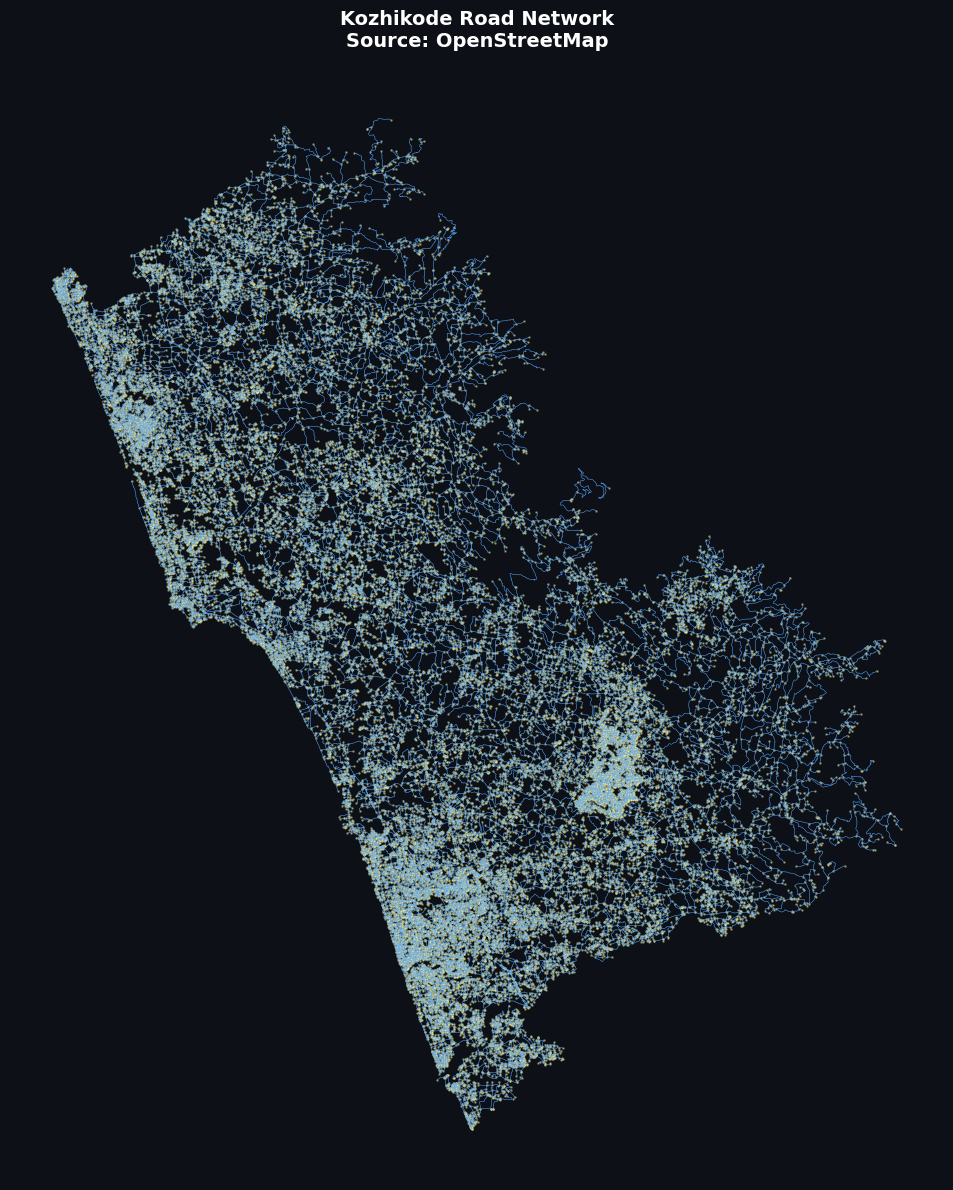

Saved: 03_kozhikode_road_network.png


In [3]:
# Cell 3 — Visualize Kozhikode street network
fig, ax = plt.subplots(figsize=(12, 12), facecolor='#0d1117')

edges.plot(
    ax=ax,
    linewidth=0.3,
    color='#58a6ff',
    alpha=0.7
)

nodes.plot(
    ax=ax,
    markersize=0.5,
    color='#f0e68c',
    alpha=0.5
)

ax.set_title("Kozhikode Road Network\nSource: OpenStreetMap",
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('../outputs/03_kozhikode_road_network.png',
            dpi=200, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Saved: 03_kozhikode_road_network.png")

In [4]:
# Cell 4 — Download Kozhikode amenities from OSM
print("Downloading amenities...")

# Hospitals
hospitals = ox.features_from_place(
    "Kozhikode, Kerala, India",
    tags={"amenity": "hospital"}
)

# Schools
schools = ox.features_from_place(
    "Kozhikode, Kerala, India",
    tags={"amenity": "school"}
)

# Banks
banks = ox.features_from_place(
    "Kozhikode, Kerala, India",
    tags={"amenity": "bank"}
)

# Keep only point geometries for clean mapping
hospitals_pts = hospitals[hospitals.geometry.geom_type == 'Point'].copy()
schools_pts = schools[schools.geometry.geom_type == 'Point'].copy()
banks_pts = banks[banks.geometry.geom_type == 'Point'].copy()

print(f"Hospitals found: {len(hospitals_pts)}")
print(f"Schools found:   {len(schools_pts)}")
print(f"Banks found:     {len(banks_pts)}")

Hospitals found: 315
Schools found:   648
Banks found:     356


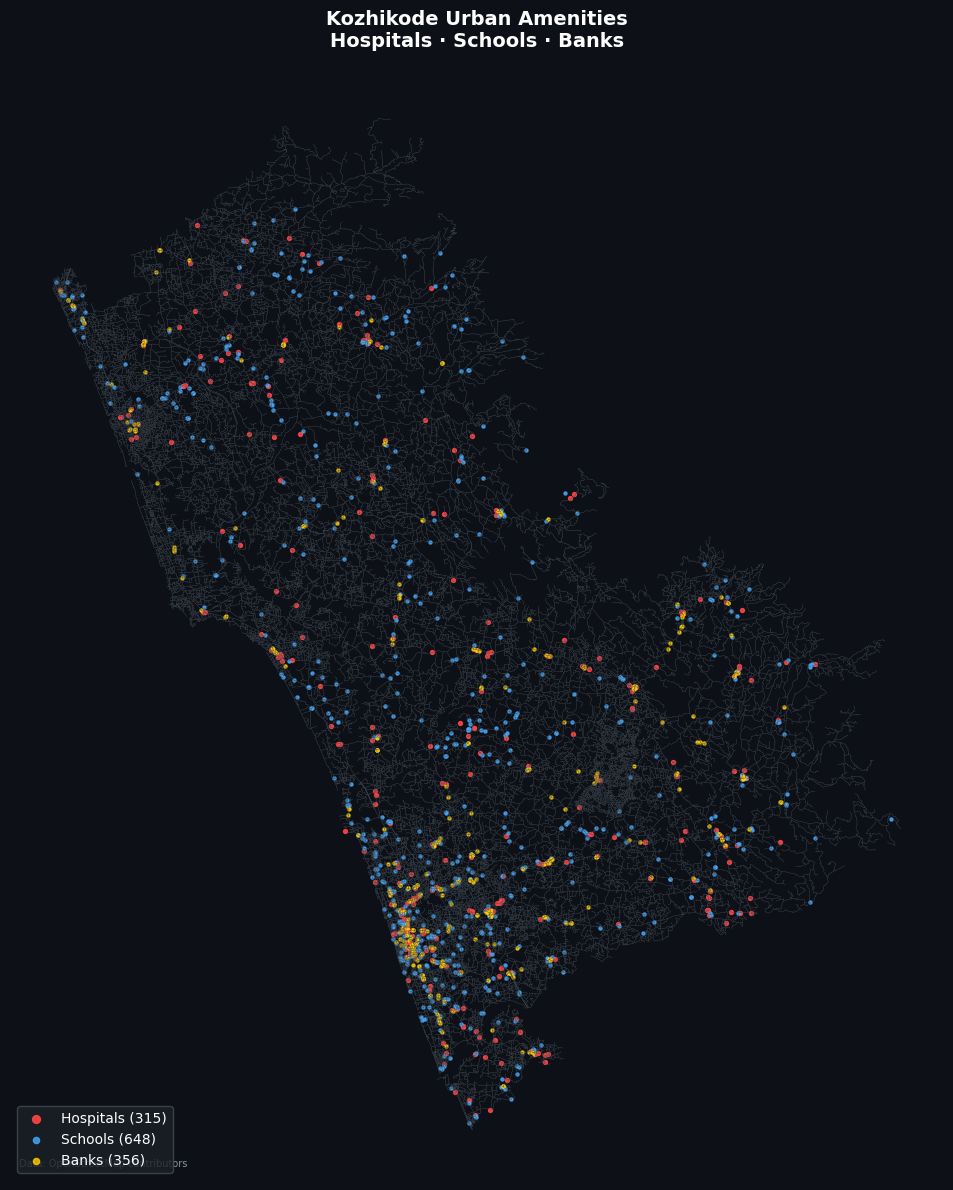

Saved: 04_kozhikode_amenities.png


In [5]:
# Cell 5 — Multi-layer amenity map
fig, ax = plt.subplots(figsize=(12, 12), facecolor='#0d1117')

# Base layer — roads
edges.plot(
    ax=ax,
    linewidth=0.2,
    color='#444d56',
    alpha=0.8
)

# Amenity layers
hospitals_pts.plot(
    ax=ax,
    markersize=8,
    color='#ff4444',
    alpha=0.9,
    label=f'Hospitals ({len(hospitals_pts)})'
)

schools_pts.plot(
    ax=ax,
    markersize=5,
    color='#44aaff',
    alpha=0.8,
    label=f'Schools ({len(schools_pts)})'
)

banks_pts.plot(
    ax=ax,
    markersize=5,
    color='#ffcc00',
    alpha=0.8,
    label=f'Banks ({len(banks_pts)})'
)

# Legend
legend = ax.legend(
    loc='lower left',
    fontsize=10,
    facecolor='#1c2128',
    edgecolor='#444d56',
    labelcolor='white',
    markerscale=2
)

ax.set_title("Kozhikode Urban Amenities\nHospitals · Schools · Banks",
             color='white', fontsize=14, fontweight='bold', pad=15)

# Add data source
ax.text(0.01, 0.01, 'Data: OpenStreetMap contributors',
        transform=ax.transAxes, color='#8b949e',
        fontsize=7, va='bottom')

ax.set_axis_off()
plt.tight_layout()
plt.savefig('../outputs/04_kozhikode_amenities.png',
            dpi=200, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Saved: 04_kozhikode_amenities.png")

In [6]:
# Cell 6 — Hospital service area analysis
print("Running hospital coverage analysis...")

# Reproject to UTM Zone 43N for accurate metre-based buffering
hospitals_utm = hospitals_pts.to_crs(epsg=32643)
edges_utm = edges.to_crs(epsg=32643)

# Create 1km and 2km buffers around each hospital
buffer_1km = hospitals_utm.buffer(1000)
buffer_2km = hospitals_utm.buffer(2000)

# Dissolve all buffers into single coverage zones
coverage_1km = buffer_1km.unary_union
coverage_2km = buffer_2km.unary_union

# Get Kozhikode boundary
boundary = ox.geocode_to_gdf("Kozhikode, Kerala, India")
boundary_utm = boundary.to_crs(epsg=32643)

# Find area NOT covered within 2km of any hospital
uncovered = boundary_utm.geometry.difference(coverage_2km)

# Calculate coverage statistics
total_area = boundary_utm.geometry.area.sum() / 1e6
covered_area = coverage_2km.area / 1e6
uncovered_area = uncovered.area.sum() / 1e6
coverage_pct = (covered_area / total_area) * 100

print(f"Total Kozhikode area:     {total_area:.1f} km²")
print(f"Area within 2km hospital: {covered_area:.1f} km²")
print(f"Uncovered area:           {uncovered_area:.1f} km²")
print(f"Coverage percentage:      {coverage_pct:.1f}%")

Running hospital coverage analysis...
Total Kozhikode area:     2349.0 km²
Area within 2km hospital: 1356.5 km²
Uncovered area:           1088.7 km²
Coverage percentage:      57.7%


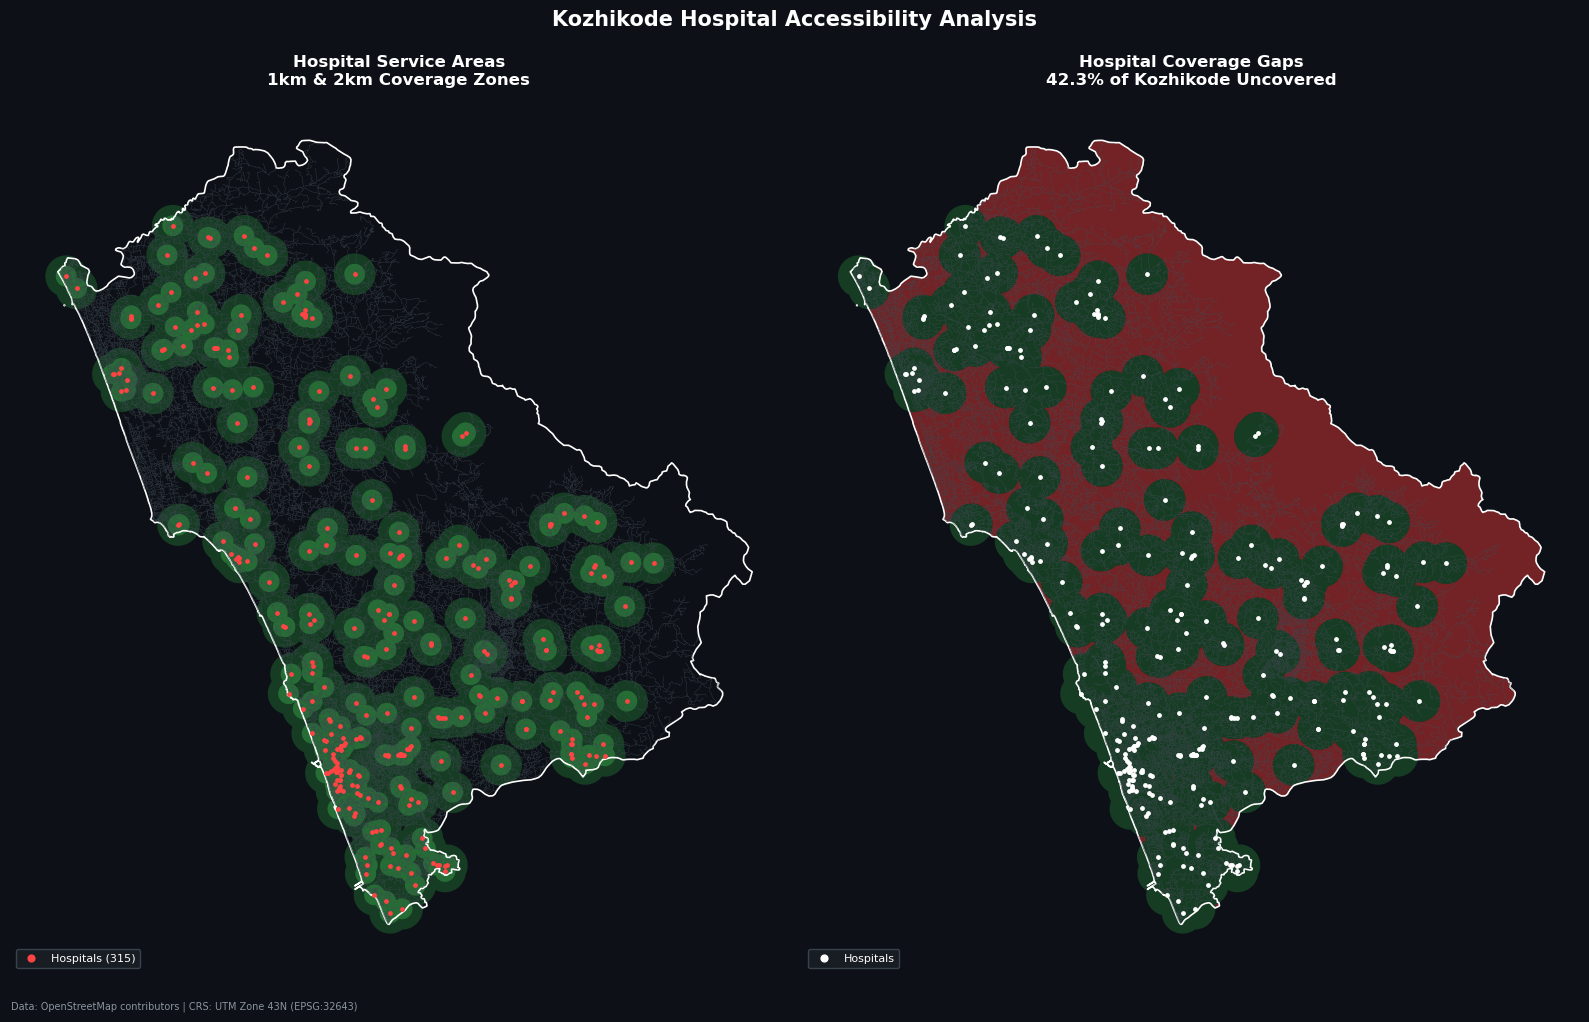

Saved: 05_kozhikode_hospital_coverage.png


In [7]:
# Cell 7 — Map hospital coverage gaps
import geopandas as gpd
from shapely.geometry import shape

# Convert coverage zones to GeoDataFrames for plotting
coverage_2km_gdf = gpd.GeoDataFrame(
    geometry=[coverage_2km],
    crs='epsg:32643'
)

coverage_1km_gdf = gpd.GeoDataFrame(
    geometry=[buffer_1km.unary_union],
    crs='epsg:32643'
)

uncovered_gdf = gpd.GeoDataFrame(
    geometry=uncovered,
    crs='epsg:32643'
).reset_index(drop=True)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 10), facecolor='#0d1117')

for ax in axes:
    ax.set_facecolor('#0d1117')

# Left map — coverage zones
edges_utm.plot(ax=axes[0], linewidth=0.2, color='#444d56', alpha=0.6)
coverage_2km_gdf.plot(ax=axes[0], color='#2ea043', alpha=0.3, label='Within 2km')
coverage_1km_gdf.plot(ax=axes[0], color='#3fb950', alpha=0.4, label='Within 1km')
hospitals_utm.plot(ax=axes[0], markersize=6, color='#ff4444',
                   zorder=5, label=f'Hospitals ({len(hospitals_utm)})')
boundary_utm.plot(ax=axes[0], color='none', edgecolor='white',
                  linewidth=1.2)

axes[0].set_title("Hospital Service Areas\n1km & 2km Coverage Zones",
                  color='white', fontsize=12, fontweight='bold', pad=12)
axes[0].legend(loc='lower left', fontsize=8, facecolor='#1c2128',
               edgecolor='#444d56', labelcolor='white', markerscale=2)
axes[0].set_axis_off()

# Right map — uncovered areas
edges_utm.plot(ax=axes[1], linewidth=0.2, color='#444d56', alpha=0.6)
uncovered_gdf.plot(ax=axes[1], color='#da3633', alpha=0.5,
                   label=f'Uncovered ({uncovered_area:.0f} km²)')
coverage_2km_gdf.plot(ax=axes[1], color='#2ea043', alpha=0.3,
                      label=f'Covered ({covered_area:.0f} km²)')
hospitals_utm.plot(ax=axes[1], markersize=6, color='white', zorder=5,
                   label='Hospitals')
boundary_utm.plot(ax=axes[1], color='none', edgecolor='white', linewidth=1.2)

axes[1].set_title("Hospital Coverage Gaps\n42.3% of Kozhikode Uncovered",
                  color='white', fontsize=12, fontweight='bold', pad=12)
axes[1].legend(loc='lower left', fontsize=8, facecolor='#1c2128',
               edgecolor='#444d56', labelcolor='white', markerscale=2)
axes[1].set_axis_off()

# Overall title
fig.suptitle("Kozhikode Hospital Accessibility Analysis",
             color='white', fontsize=15, fontweight='bold', y=1.01)

# Data source
fig.text(0.01, 0.01, 'Data: OpenStreetMap contributors | CRS: UTM Zone 43N (EPSG:32643)',
         color='#8b949e', fontsize=7)

plt.tight_layout()
plt.savefig('../outputs/05_kozhikode_hospital_coverage.png',
            dpi=200, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Saved: 05_kozhikode_hospital_coverage.png")